### Step 1: Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [232]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [229]:
from sklearn.model_selection import train_test_split
from sklearn import metrics

In [56]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras import Model, layers, utils, callbacks, optimizers, regularizers
from tensorflow import data

In [4]:
import albumentations as A

### Step 2: Constant

In [207]:
AUTO = data.experimental.AUTOTUNE
EPOCHS = 200
BATCH_SIZE = 128
NUM_CLASSES = 10
VERSION = 1
DEPTH = 20 if VERSION==1 else 29
IMG_HEIGH = 32
IMG_WIDTH = 32
IMG_CHANNEL = 3
SAVE_DIR = './saved_models/'
MODEL_TYPE = 'ResNet %dv%d' % (DEPTH, VERSION)
SAVE_PATH = os.path.join(SAVE_DIR, 'cifar10_%s_model.{epoch:03d}.keras' % MODEL_TYPE)

### Step 3: Load Data

In [52]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

In [ ]:
cifar1

### Step 4: Exploaring Data

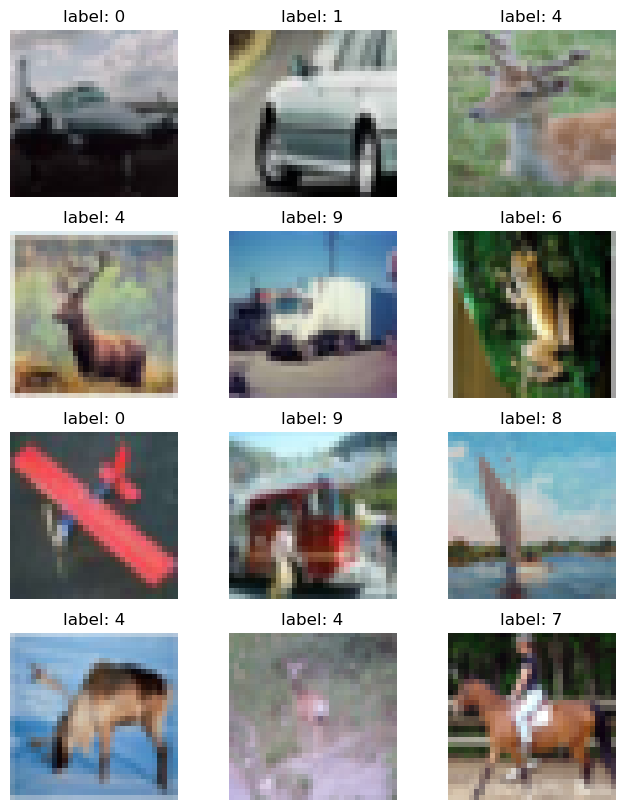

In [7]:
plt.figure(figsize=(8, 10))
for i in range(12):
    plt.subplot(4, 3, i+1)
    k = np.random.randint(X_train.shape[0])
    label = y_train[k][0]
    img = X_train[k]
    plt.imshow(img)
    plt.title(f'label: {label}')
    plt.axis('off')

### Step 4: Preparing Data

#### Split Data

In [67]:
X_train, X_value, y_train, y_value = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42
)

In [84]:
img_mean = np.mean(X_train.astype('float32')/255, axis=0)

#### Albumentation

In [169]:
transform = A.Compose(
    [
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.CoarseDropout(p=0.2),
        A.RandomGamma(p=0.2),
        A.RandomBrightnessContrast(p=0.2)
    ]
)

#### Build Generator

In [170]:
def generator(datas, labels, img_shape, is_train):
    def gen():
        for i in range(len(datas)):
            img = datas[i]
            label = labels[i][0]
            if is_train:
                img = transform(image=img)['image']
            img = img.astype('float32') / 255.0
            img -= img_mean
            yield img, label
            
    return data.Dataset.from_generator(
        gen,
        output_signature=(
            tf.TensorSpec(shape=img_shape, dtype=tf.float32),
            tf.TensorSpec(shape=(), dtype=tf.uint8)
        )
    )

In [171]:
def get_generator(datas, labels, batch_size, img_shape, is_train=True):
    gen = generator(datas, labels, img_shape, is_train)
    gen = gen.map(
        lambda x, y: (x, tf.one_hot(y, NUM_CLASSES))
    )
    if is_train:
        gen = gen.shuffle(min(len(datas), 1000))
    gen = gen.batch(batch_size)
    gen = gen.prefetch(AUTO)
    return gen

In [172]:
train_generator = get_generator(X_train, y_train, BATCH_SIZE, (IMG_HEIGH, IMG_WIDTH, IMG_CHANNEL))
value_generator = get_generator(X_value, y_value, BATCH_SIZE, (IMG_HEIGH, IMG_WIDTH, IMG_CHANNEL), is_train=False)
test_generator = get_generator(X_test, y_test, BATCH_SIZE, (IMG_HEIGH, IMG_WIDTH, IMG_CHANNEL), is_train=False)

In [173]:
for img, label in test_generator.take(1):
    print(img.shape, label.shape)

(128, 32, 32, 3) (128, 10)


### Step 5: Model Development

#### Build Model

In [193]:
def resnet_layer(inputs, num_filters=16, kernel_size=3, strides=1, activation='relu', batch_normalization=True, conv_first=True):
    conv = layers.Conv2D(
        num_filters,
        kernel_size=kernel_size,
        strides=strides,
        padding='same',
        kernel_initializer='he_normal',
        kernel_regularizer=regularizers.l2(1e-4)
    )

    x = inputs
    if conv_first:
        x = conv(x)
        if batch_normalization:
            x = layers.BatchNormalization()(x)
        if activation is not None:
            x = layers.Activation(activation)(x)
    else:
        if batch_normalization:
            x = layers.BatchNormalization()(x)
        if activation is not None:
            x = layers.Activation(activation)(x)
        x = conv(x)
    return x

In [104]:
def resnet_v1(input_shape, depth, num_classes=10):
    if (depth - 2) % 6 != 0:
        raise ValueError('depth should be 6n + 2')

    num_filters = 16
    num_res_blocks = int((depth - 2) / 6)
    inputs = layers.Input(shape=input_shape)
    x = resnet_layer(inputs=inputs)

    for stack in range(3):
        for res_block in range(num_res_blocks):
            strides = 1
            if stack > 0 and res_block == 0:
                strides = 2  # Downsample
            y = resnet_layer(x, num_filters=num_filters, strides=strides)
            y = resnet_layer(y, num_filters=num_filters, activation=None)
            if stack > 0 and res_block == 0:
                x = resnet_layer(x, num_filters=num_filters, kernel_size=1,
                                 strides=strides, activation=None, batch_normalization=False)
            x = layers.Add()([x, y])
            x = layers.Activation('relu')(x)
        num_filters *= 2

    x = layers.AveragePooling2D(pool_size=8)(x)
    y = layers.Flatten()(x)
    outputs = layers.Dense(num_classes, activation='softmax', kernel_initializer='he_normal')(y)
    model = Model(inputs=inputs, outputs=outputs)
    return model

In [194]:
def resnet_v2(input_shape, depth, num_classes=10):
    if (depth - 2) % 9 != 0:
        raise ValueError('depth should be 9n + 2')

    num_filters_in = 16
    num_res_blocks = int((depth - 2) / 9)
    inputs = layers.Input(shape=input_shape)
    x = resnet_layer(inputs, num_filters=num_filters_in, conv_first=True)

    for stage in range(3):
        for res_block in range(num_res_blocks):
            activation = 'relu'
            batch_normalization = True
            strides = 1
            if stage == 0:
                num_filters_out = num_filters_in * 4
                if res_block == 0:
                    activation = None
                    batch_normalization = False
            else:
                num_filters_out = num_filters_in * 2
                if res_block == 0:
                    strides = 2
            y = resnet_layer(x, num_filters=num_filters_in, kernel_size=1,
                             strides=strides, activation=activation,
                             batch_normalization=batch_normalization, conv_first=False)
            y = resnet_layer(y, num_filters=num_filters_in, conv_first=False)
            y = resnet_layer(y, num_filters=num_filters_out, kernel_size=1, conv_first=False)
            if res_block == 0:
                x = resnet_layer(x, num_filters=num_filters_out, kernel_size=1,
                                 strides=strides, activation=None, batch_normalization=False)
            x = layers.Add()([x, y])
        num_filters_in = num_filters_out

    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.AveragePooling2D(pool_size=8)(x)
    y = layers.Flatten()(x)
    outputs = layers.Dense(num_classes, activation='softmax', kernel_initializer='he_normal')(y)
    model = Model(inputs=inputs, outputs=outputs)
    return model

In [208]:
if VERSION == 2:
    model = resnet_v2(input_shape=(IMG_HEIGH, IMG_WIDTH, IMG_CHANNEL), depth=DEPTH, num_classes=NUM_CLASSES)
else:
    model = resnet_v1(input_shape=(IMG_HEIGH, IMG_WIDTH, IMG_CHANNEL), depth=DEPTH, num_classes=NUM_CLASSES)

In [196]:
model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)    │ (None, 32, 32, 3)         │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_111 (Conv2D)           │ (None, 32, 32, 16)        │             448 │ input_layer_9[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_98        │ (None, 32, 32, 16)        │              64 │ conv2d_111[0][0]           │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_98 (Activation)    │ (None, 32, 32, 16)        │               0 │ batch_normalization_98[0]… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_112 (Conv2D)           │ (None, 32, 32, 16)        │             272 │ activation_98[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_99        │ (None, 32, 32, 16)        │              64 │ conv2d_112[0][0]           │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_99 (Activation)    │ (None, 32, 32, 16)        │               0 │ batch_normalization_99[0]… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_113 (Conv2D)           │ (None, 32, 32, 16)        │           2,320 │ activation_99[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_100       │ (None, 32, 32, 16)        │              64 │ conv2d_113[0][0]           │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_100 (Activation)   │ (None, 32, 32, 16)        │               0 │ batch_normalization_100[0… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_115 (Conv2D)           │ (None, 32, 32, 64)        │           1,088 │ activation_98[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_114 (Conv2D)           │ (None, 32, 32, 64)        │           1,088 │ activation_100[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add_45 (Add)                  │ (None, 32, 32, 64)        │               0 │ conv2d_115[0][0],          │
│                               │                           │                 │ conv2d_114[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_101       │ (None, 32, 32, 64)        │             256 │ add_45[0][0]               │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_101 (Activation)   │ (None, 32, 32, 64)        │               

 Total params: 849,002 (3.24 MB)

 Trainable params: 843,786 (3.22 MB)

 Non-trainable params: 5,216 (20.38 KB)

In [197]:
utils.plot_model(
    model,
    show_shapes=True,
    show_dtype=True,
    show_layer_names=True,
    show_layer_activations=True
)

#### Compile Model

In [209]:
optimizer = optimizers.Adam(learning_rate=0.001, clipnorm=1.0)

In [210]:
model.compile(
    loss='categorical_crossentropy',
    optimizer=optimizer,
    metrics=['accuracy']
)

#### Train Model

In [211]:
def lr_schedule(epoch):
    lr = 1e-3
    if epoch > 180:
        lr *= 0.5e-3
    elif epoch > 160:
        lr *= 1e-3
    elif epoch > 120:
        lr *= 1e-2
    elif epoch > 80:
        lr *= 1e-1
    return lr

In [212]:
checkpoint = callbacks.ModelCheckpoint(
    filepath=SAVE_PATH,
    monitor='val_accuracy',
    verbose=0,
    save_best_only=True
)

In [213]:
lr_scheduler = callbacks.LearningRateScheduler(lr_schedule)

In [214]:
lr_reducer = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=np.sqrt(0.1),
    patience=5,
    min_lr=0.5e-6
)

In [215]:
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    verbose=0,
    restore_best_weights=True
)

In [216]:
history_v1 = model.fit(
    train_generator,
    validation_data=value_generator,
    epochs=EPOCHS,
    callbacks=[checkpoint, lr_reducer, lr_scheduler, early_stopping]
)

Epoch 1/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 54s 145ms/step - accuracy: 0.3892 - loss: 1.8358 - val_accuracy: 0.3123 - val_loss: 2.2840 - learning_rate: 0.0010
Epoch 2/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 46s 147ms/step - accuracy: 0.5326 - loss: 1.4433 - val_accuracy: 0.5147 - val_loss: 1.5240 - learning_rate: 0.0010
Epoch 3/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 51s 163ms/step - accuracy: 0.5910 - loss: 1.2856 - val_accuracy: 0.5035 - val_loss: 1.5636 - learning_rate: 0.0010
Epoch 4/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 53s 169ms/step - accuracy: 0.6321 - loss: 1.1713 - val_accuracy: 0.5425 - val_loss: 1.5274 - learning_rate: 0.0010
Epoch 5/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 54s 172ms/step - accuracy: 0.6546 - loss: 1.1120 - val_accuracy: 0.5445 - val_loss: 1.4076 - learning_rate: 0.0010
Epoch 6/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 54s 171ms/step - accuracy: 0.6761 - loss: 1.0501 - val_accuracy: 0.5768 - val_loss: 1.3610 - learning_rate: 0.0010
Epoch 7/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 53s 170ms/step - accura

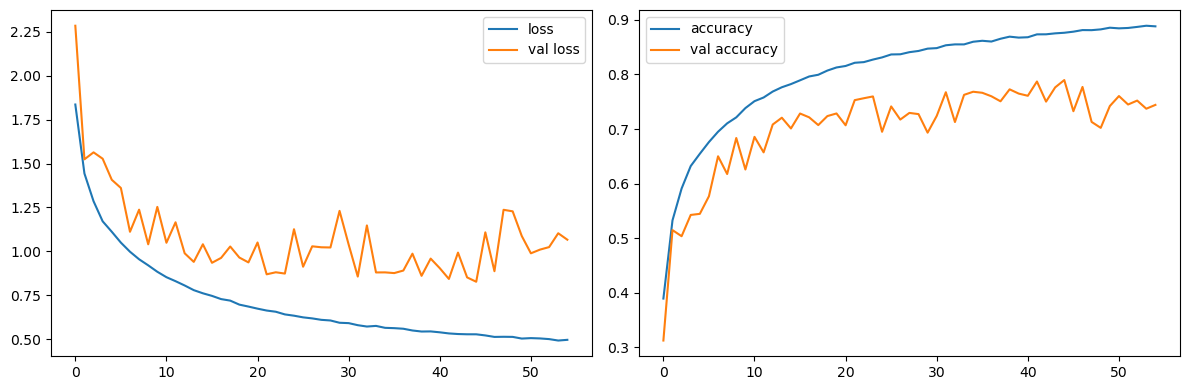

In [218]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_v1.history['loss'], label='loss')
plt.plot(history_v1.history['val_loss'], label='val loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history_v1.history['accuracy'], label='accuracy')
plt.plot(history_v1.history['val_accuracy'], label='val accuracy')
plt.legend()
plt.tight_layout()

In [206]:
history_v2 = model.fit(
    train_generator,
    validation_data=value_generator,
    epochs=EPOCHS,
    callbacks=[checkpoint, lr_reducer, lr_scheduler, early_stopping]
)

Epoch 1/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 138s 408ms/step - accuracy: 0.4008 - loss: 2.1524 - val_accuracy: 0.3338 - val_loss: 2.3665 - learning_rate: 0.0010
Epoch 2/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 139s 444ms/step - accuracy: 0.5277 - loss: 1.7251 - val_accuracy: 0.5273 - val_loss: 1.7038 - learning_rate: 0.0010
Epoch 3/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 140s 448ms/step - accuracy: 0.5928 - loss: 1.5065 - val_accuracy: 0.5582 - val_loss: 1.6338 - learning_rate: 0.0010
Epoch 4/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 142s 453ms/step - accuracy: 0.6305 - loss: 1.3712 - val_accuracy: 0.5520 - val_loss: 1.6623 - learning_rate: 0.0010
Epoch 5/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 141s 449ms/step - accuracy: 0.6589 - loss: 1.2727 - val_accuracy: 0.5636 - val_loss: 1.6040 - learning_rate: 0.0010
Epoch 6/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 141s 450ms/step - accuracy: 0.6823 - loss: 1.1987 - val_accuracy: 0.6422 - val_loss: 1.2767 - learning_rate: 0.0010
Epoch 7/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 143s 456ms/step -

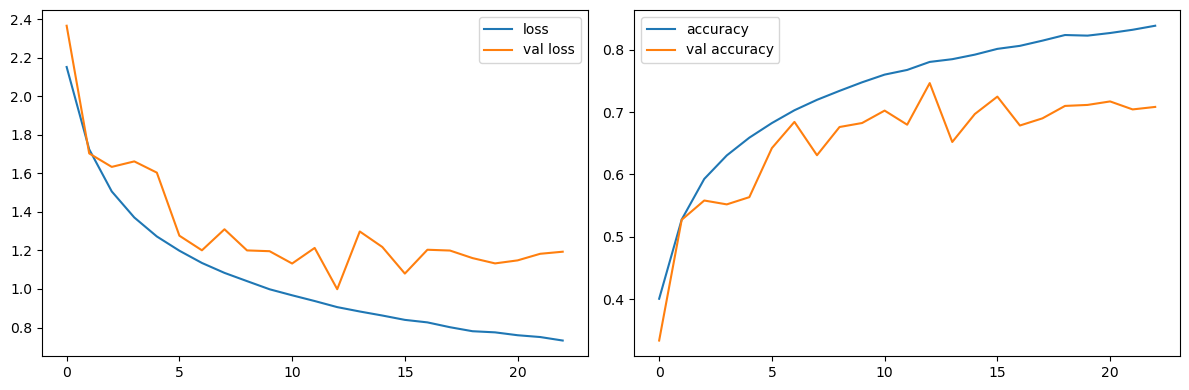

In [221]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_v2.history['loss'], label='loss')
plt.plot(history_v2.history['val_loss'], label='val loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history_v2.history['accuracy'], label='accuracy')
plt.plot(history_v2.history['val_accuracy'], label='val accuracy')
plt.legend()
plt.tight_layout()

#### Evaluate Model

In [223]:
loss, accuracy = model.evaluate(test_generator, verbose=0)
print(f'test loss: {round(loss, 3)}, test accuracy: {round(accuracy, 3)}')

test loss: 0.864, test accuracy: 0.783


In [224]:
test_pred = model.predict(test_generator)

79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step


In [230]:
confuse_matrix = metrics.confusion_matrix(y_test.flatten(), np.argmax(test_pred, axis=1))

In [235]:
labels = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]

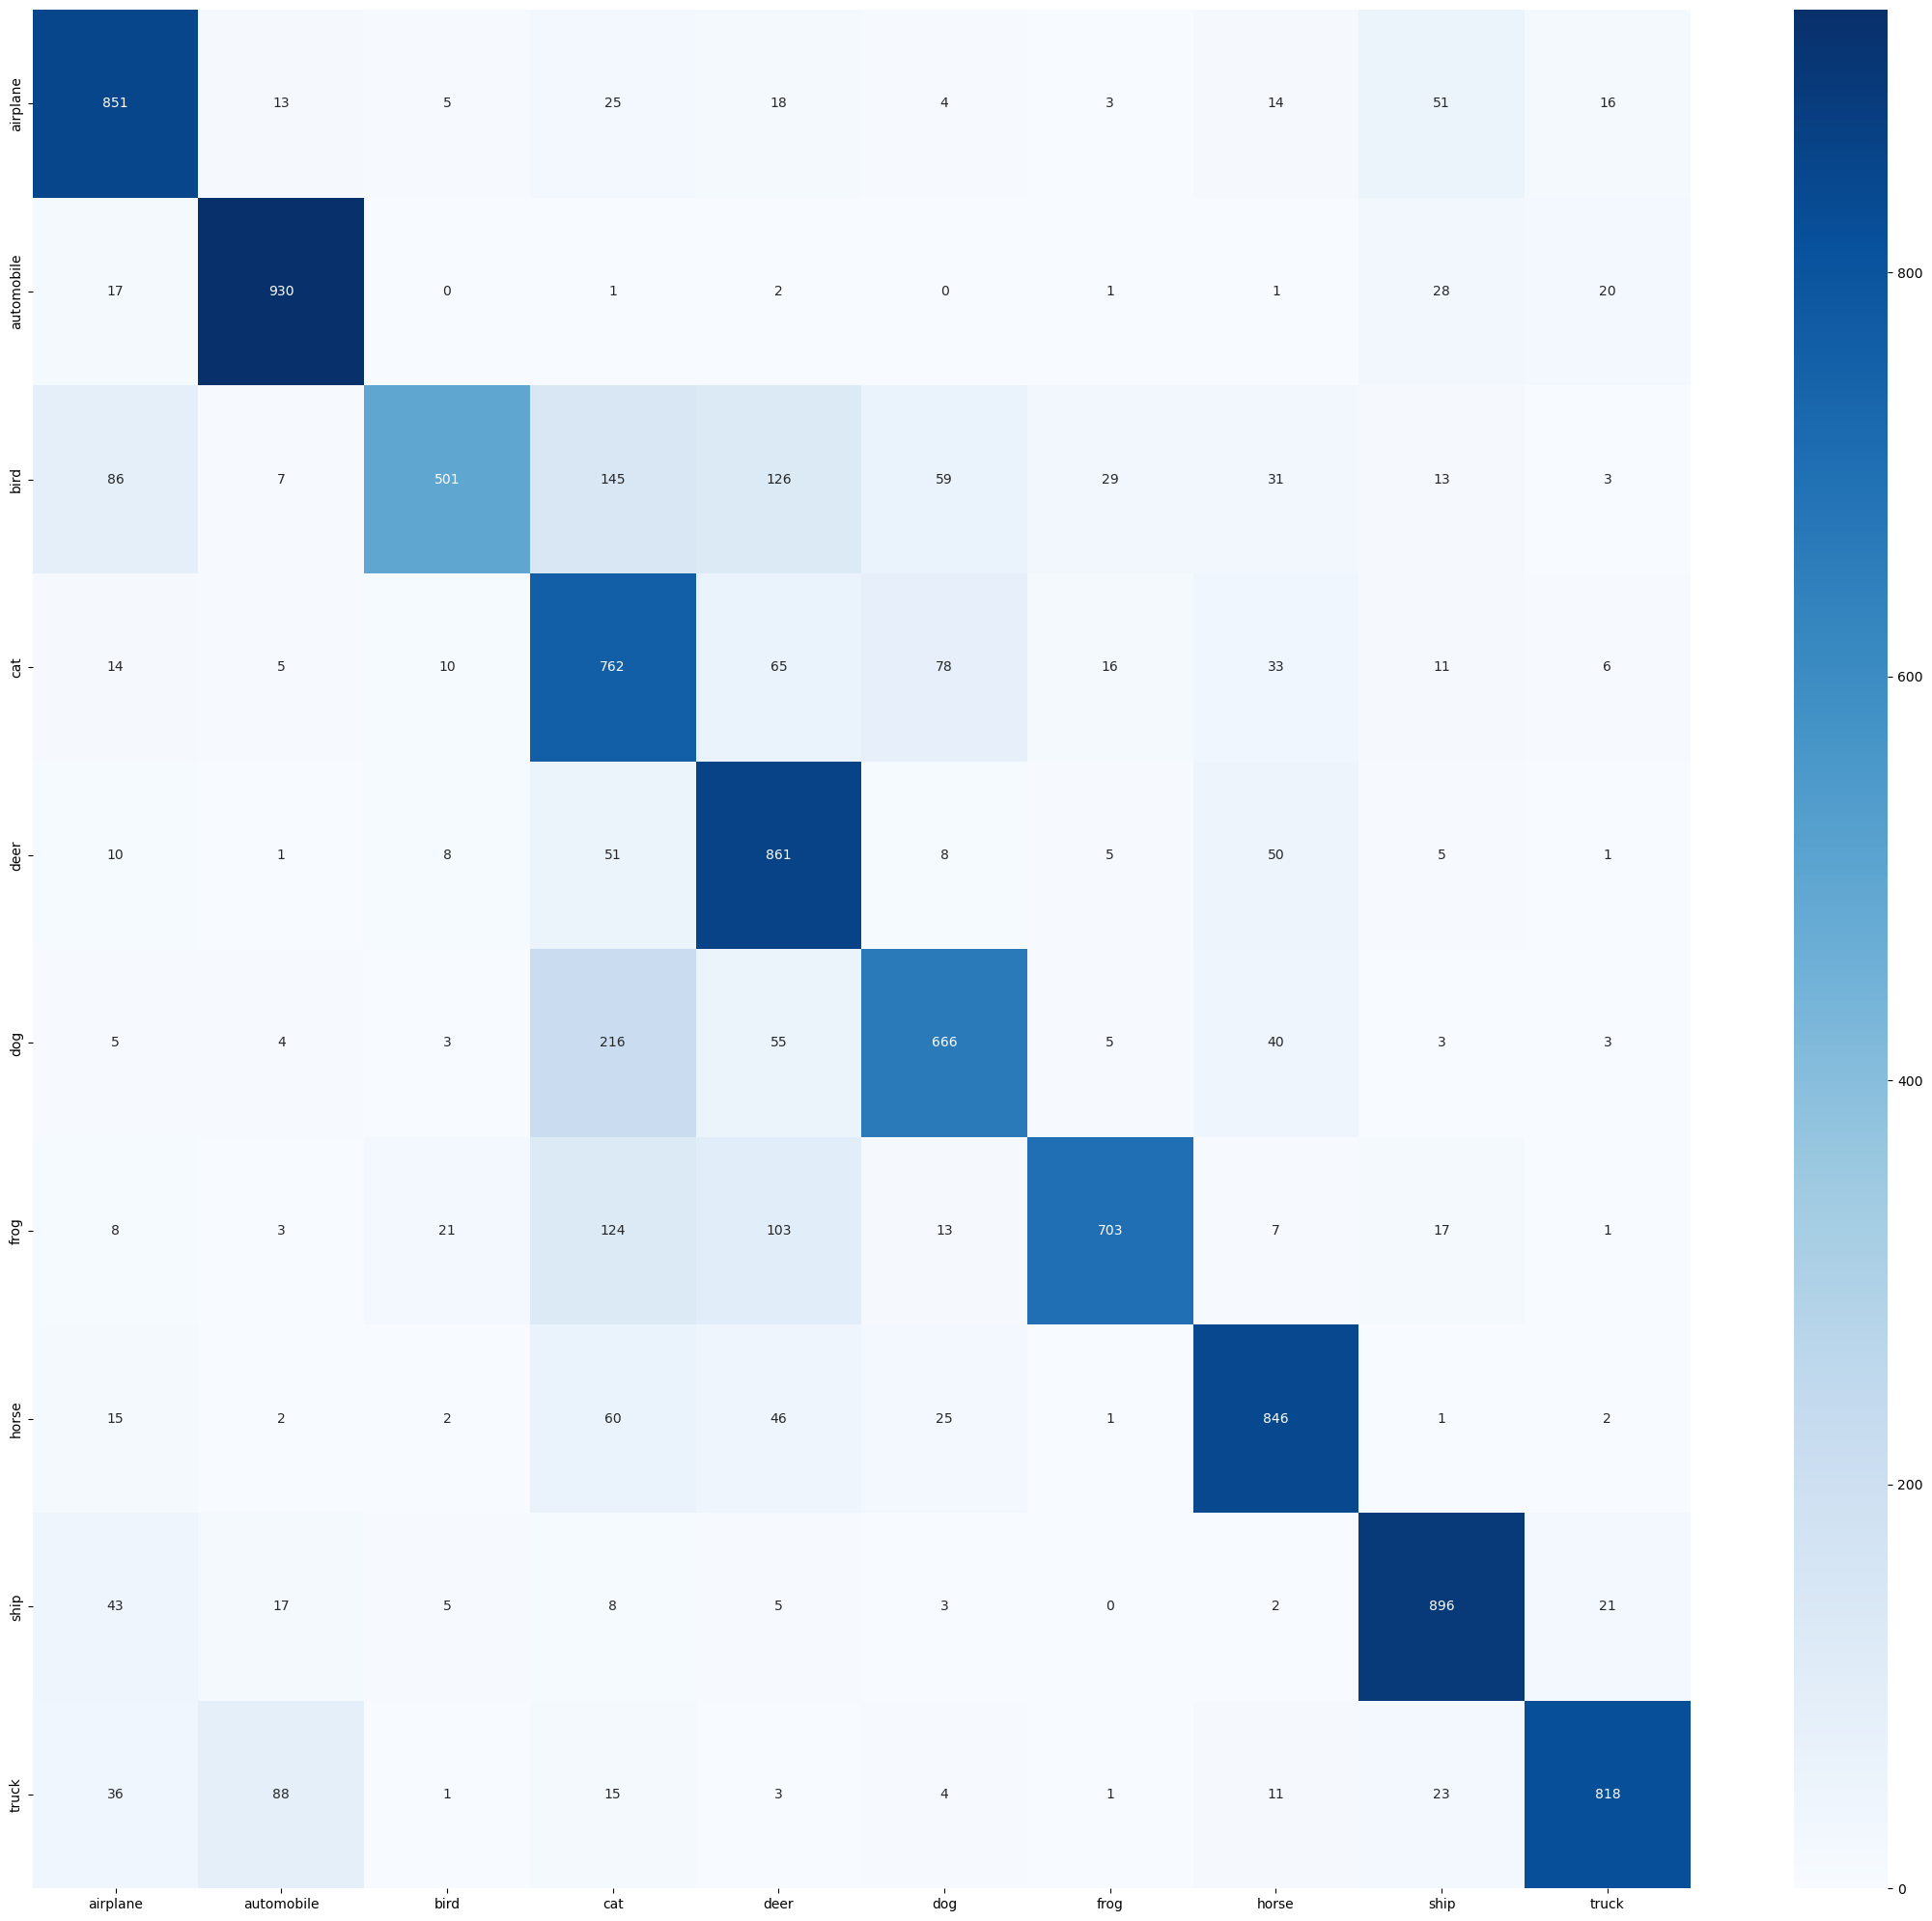

In [236]:
plt.figure(figsize=(22, 20))
sns.heatmap(
    confuse_matrix,
    fmt='d',
    annot=True,
    cmap=plt.cm.Blues,
    xticklabels=labels,
    yticklabels=labels
)
plt.tight_layout()